In [1]:
from langgraph.graph import START, END, StateGraph
from langchain_ollama import ChatOllama
from typing import TypedDict, Literal, Optional
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import pandas as pd
import os
import json
from get_coordinates import get_city_coordinates
from air_quality import (
    get_current_air_quality,
    get_forecast_air_quality,
    clean_air_quality_data, 
    plot_air_quality_data
)
from weather import (
    get_current_weather,
    get_forecast_weather,
    clean_forecast_weather_data,
    plot_temperature_data,
    plot_rain_data,
    plot_wind_data
)
load_dotenv()

True

In [2]:
model = ChatOllama(
    model="deepseek-r1:1.5b",
    temperature=0.3,
    reasoning=True
)

In [3]:
# output = model.invoke("What course you would recommend to take a fresher studying in Computer Science?")
# output

AIMessage(content="As a fresher studying in Computer Science, here's a structured plan based on your thought process:\n\n1. **Begin with CS 103: Introduction to Computer Science**\n   - **Objective:** Build foundational programming skills using Java.\n   - **Content:** Covers basic programming concepts, data types, control structures, and problem-solving techniques.\n\n2. **Proceed to CS 205: Data Structures and Algorithms**\n   - **Objective:** Develop expertise in managing and manipulating data efficiently.\n   - **Content:** Explores arrays, linked lists, trees, graphs, sorting algorithms, searching methods, and algorithmic efficiency.\n\n3. **Take CS 224: Theory of Computation**\n   - **Objective:** Understand the theoretical foundations of computing.\n   - **Content:** Covers automata theory, formal languages, computability, and complexity analysis.\n\n4. **Conclude with CS 396: Senior Project or Research**\n   - **Objective:** Apply knowledge through a capstone project.\n   - **C

In [4]:
# output.pretty_print()

================================== Ai Message ==================================

As a fresher studying in Computer Science, here's a structured plan based on your thought process:

1. **Begin with CS 103: Introduction to Computer Science**
   - **Objective:** Build foundational programming skills using Java.
   - **Content:** Covers basic programming concepts, data types, control structures, and problem-solving techniques.

2. **Proceed to CS 205: Data Structures and Algorithms**
   - **Objective:** Develop expertise in managing and manipulating data efficiently.
   - **Content:** Explores arrays, linked lists, trees, graphs, sorting algorithms, searching methods, and algorithmic efficiency.

3. **Take CS 224: Theory of Computation**
   - **Objective:** Understand the theoretical foundations of computing.
   - **Content:** Covers automata theory, formal languages, computability, and complexity analysis.

4. **Conclude with CS 396: Senior Project or Research**
   - **Objective:** Apply

In [10]:
from pydantic import BaseModel, Field
from typing import Literal

class AirQuerySchema(BaseModel):
    query_type: Literal["current", "forecast"] = Field(
        description="Pick one of the air_quality query_type: 'current' or 'forecast'"
    )
    city_name: str = Field(description="City Name")
    country_code: str = Field(description="Country Code in ISO-3166-1 alpha-2")

def air_query_prompt(user_input: str) -> str:
    return (
        "Extract structured information from this air quality query:\n"
        "Output as JSON with keys: query_type (either 'current' or 'forecast'), city_name, country_code (ISO-2 code if possible).\n\n"
        f"User query: {user_input}\n"
        "Example output: {\"query_type\": \"forecast\", \"city_name\": \"Delhi\", \"country_code\": \"IN\"}\n"
    )

def get_air_query_inputs(user_input: str, model=model) -> AirQuerySchema:
    prompt = air_query_prompt(user_input)
    model.with_structured_output(AirQuerySchema)
    result = model.invoke(prompt)
    text = result.content.strip()
    # Extract JSON part from response
    try:
        data = json.loads(text)
        schema = AirQuerySchema(**data)
    except Exception as e:
        print("Error parsing LLM response:", e)
        # Optionally fallback or handle manual extraction/ask model to try again
        schema = None
    return schema

In [11]:
obj = get_air_query_inputs("What is Air Quality of Delhi, India?", model=model)
obj

Error parsing LLM response: Expecting value: line 1 column 1 (char 0)


In [ ]:
class AirWFState(TypedDict, total=False):
    user_prompt: str
    query_type: Literal["current", "forecast"]
    city_name: str
    country_code: str
    lat: float
    lon: float
    raw_data: dict
    df: pd.DataFrame
    make_plot: bool
    plot: str

In [ ]:
def start_air_graph(state: AirWFState) -> AirWFState:
    # Use LLM to get structured inputs
    user_prompt = state["user_prompt"]
    schema = get_air_query_inputs(user_prompt, model = model)
    if schema is None:
        raise ValueError("Failed to extract info from user prompt.")
    return {
        **state,
        "query_type": schema.query_type,
        "city_name": schema.city_name,
        "country_code": schema.country_code
    }

def resolve_coords(state: AirWFState) -> AirWFState:
    coords = get_city_coordinates(state['city_name'], country_code=state['country_code'])
    lat = coords['lat']
    lon = coords['lon']
    return {**state, "lat": lat, "lon": lon}

def route_air_query(state: AirWFState) -> str:
    if state['query_type'] == "current":
        return "run_current_air"
    elif state['query_type'] == "forecast":
        return "run_forecast_air"
    else:
        raise ValueError(f"Unknown query_type: {state['query_type']}")
        
def run_current_air(state: AirWFState) -> AirWFState:
    data = get_current_air_quality(state["lat"], state["lon"])
    return {**state, "raw_data": data, "make_plot": False}

def run_forecast_air(state: AirWFState) -> AirWFState:
    data = get_forecast_air_quality(state["lat"], state["lon"])
    return {**state, "raw_data": data, "make_plot": True}

def clean_air_response(state: AirWFState) -> AirWFState:
    if state['query_type'] == "current":
        raw_list = state['raw_data'].get("list") if isinstance(state['raw_data'], dict) else state['raw_data']
        df = clean_air_quality_data(raw_list)
        return {**state, "df": df}
    elif state['query_type'] == "forecast":
        df = clean_air_quality_data(state['raw_data'])
        return {**state, "df": df}

def plot_forecast_air(state: AirWFState) -> AirWFState:
    if state.get("make_plot"):
        plot = plot_air_quality_data(state["df"], return_base64=True)
        return {**state, "plot": plot}
    return state

In [ ]:
air_graph = StateGraph(AirWFState)

air_graph.add_node("start_air_graph", start_air_graph)
air_graph.add_node("resolve_coords", resolve_coords)
# air_graph.add_node("route_air_query", route_air_query)
air_graph.add_node("run_current_air", run_current_air)
air_graph.add_node("run_forecast_air", run_forecast_air)
air_graph.add_node("clean_air_response", clean_air_response)
air_graph.add_node("plot_forecast_air", plot_forecast_air)

air_graph.set_entry_point("start_air_graph")
air_graph.add_edge("start_air_graph", "resolve_coords")
air_graph.add_conditional_edges("resolve_coords", route_air_query)
air_graph.add_edge("run_current_air", "clean_air_response")
air_graph.add_edge("run_forecast_air", "clean_air_response")
air_graph.add_edge("clean_air_response", "plot_forecast_air")
air_graph.add_edge("plot_forecast_air", END)

air_graph_wf = air_graph.compile()

In [ ]:
air_graph_wf

In [12]:
from typing import TypedDict, Literal
import pandas as pd

# -----------------------------
# State Definition
# -----------------------------
class AirWFState(TypedDict, total=False):
    user_prompt: str
    query_type: Literal["current", "forecast"]
    city_name: str
    country_code: str
    lat: float
    lon: float
    raw_data: dict
    df: pd.DataFrame
    make_plot: bool
    plot: str

# -----------------------------
# Node Functions
# -----------------------------
def start_air_graph(state: AirWFState) -> AirWFState:
    # Use LLM to extract structured inputs
    user_prompt = state["user_prompt"]
    schema = get_air_query_inputs(user_prompt)
    if schema is None:
        raise ValueError("Failed to extract info from user prompt.")
    return {
        **state,
        "query_type": schema.query_type,
        "city_name": schema.city_name,
        "country_code": schema.country_code
    }

def resolve_coords(state: AirWFState) -> AirWFState:
    coords = get_city_coordinates(state['city_name'], country_code=state['country_code'])
    lat = coords['lat']
    lon = coords['lon']
    return {**state, "lat": lat, "lon": lon}

def route_air_query(state: AirWFState) -> str:
    if state['query_type'] == "current":
        return "run_current_air"
    elif state['query_type'] == "forecast":
        return "run_forecast_air"
    else:
        raise ValueError(f"Unknown query_type: {state['query_type']}")

def run_current_air(state: AirWFState) -> AirWFState:
    data = get_current_air_quality(state["lat"], state["lon"])
    return {**state, "raw_data": data, "make_plot": False}

def run_forecast_air(state: AirWFState) -> AirWFState:
    data = get_forecast_air_quality(state["lat"], state["lon"])
    return {**state, "raw_data": data, "make_plot": True}

def clean_air_response(state: AirWFState) -> AirWFState:
    if state['query_type'] == "current":
        raw_list = state['raw_data'].get("list") if isinstance(state['raw_data'], dict) else state['raw_data']
        df = clean_air_quality_data(raw_list)
        return {**state, "df": df}
    elif state['query_type'] == "forecast":
        df = clean_air_quality_data(state['raw_data'])
        return {**state, "df": df}
    else:
        raise ValueError(f"Invalid query_type for cleaning: {state['query_type']}")

def plot_forecast_air(state: AirWFState) -> AirWFState:
    if state.get("make_plot"):
        plot = plot_air_quality_data(state["df"], return_base64=True)
        return {**state, "plot": plot}
    return state

# -----------------------------
# Graph Definition
# -----------------------------
air_graph = StateGraph(AirWFState)

air_graph.add_node("start_air_graph", start_air_graph)
air_graph.add_node("resolve_coords", resolve_coords)
air_graph.add_node("run_current_air", run_current_air)
air_graph.add_node("run_forecast_air", run_forecast_air)
air_graph.add_node("clean_air_response", clean_air_response)
air_graph.add_node("plot_forecast_air", plot_forecast_air)

air_graph.set_entry_point("start_air_graph")
air_graph.add_edge("start_air_graph", "resolve_coords")

# conditional routing
air_graph.add_conditional_edges(
    "resolve_coords",
    route_air_query,
    {
        "run_current_air": "run_current_air",
        "run_forecast_air": "run_forecast_air"
    }
)

# shared cleaning stage
air_graph.add_edge("run_current_air", "clean_air_response")
air_graph.add_edge("run_forecast_air", "clean_air_response")

# plotting + end
air_graph.add_edge("clean_air_response", "plot_forecast_air")
air_graph.add_edge("plot_forecast_air", END)

air_graph_wf = air_graph.compile()

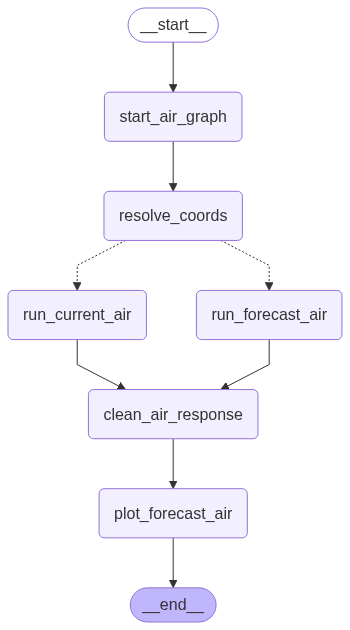

In [13]:
air_graph_wf

In [ ]:
initial_state = {"user_prompt": "What is air quality of Delhi, India?"}
final_state = air_graph_wf.invoke(initial_state)
final_state

In [ ]:
class AirCurrentState(TypedDict, total=False):
    city_name: str
    country_code: str
    lat: float
    lon: float
    raw_data: dict
    df: pd.DataFrame

In [ ]:
def resolve_coords(state: AirCurrentState) -> AirCurrentState:
    coords = get_city_coordinates(state['city_name'], country_code=state['country_code'])
    lat = coords['lat']
    lon = coords['lon']
    return {**state, "lat": lat, "lon": lon}
def fetch_current(state: AirCurrentState) -> AirCurrentState:
    data = get_current_air_quality(state["lat"], state["lon"])
    return {**state, "raw_data": data}

def clean_current(state: AirCurrentState) -> AirCurrentState:
    df = clean_air_quality_data(state["raw_data"].get("list"))
    return {**state, "df": df}

In [ ]:
graph = StateGraph(AirCurrentState)

graph.add_node("resolve_coords", resolve_coords)
graph.add_node("fetch_current", fetch_current)
graph.add_node("clean_current", clean_current)

graph.set_entry_point("resolve_coords")
graph.add_edge("resolve_coords", "fetch_current")
graph.add_edge("fetch_current", "clean_current")
graph.add_edge("clean_current", END)

air_current_wf = graph.compile()

In [ ]:
air_current_wf

In [ ]:
initial_state = {"city_name": "Katihar", "country_code": "IN"}
final_state = air_current_wf.invoke(initial_state)
final_state

In [ ]:
class AirForecastState(TypedDict, total=False):
    city_name: str
    country_code: str
    days: int
    lat: float
    lon: float
    raw_data: dict
    df: pd.DataFrame
    plot: bool
    plot_path: Optional[str]

In [ ]:
def resolve_coords(state: AirForecastState) -> AirForecastState:
    coords = get_city_coordinates(state['city_name'], country_code=state['country_code'])
    lat = coords['lat']
    lon = coords['lon']
    return {**state, "lat": lat, "lon": lon}

def fetch_forecast(state: AirForecastState) -> AirForecastState:
    data = get_forecast_air_quality(state["lat"], state["lon"])
    return {**state, "raw_data": data}

def clean_forecast(state: AirForecastState) -> AirForecastState:
    df = clean_air_quality_data(state["raw_data"].get("list"))
    return {**state, "df": df}

def maybe_plot(state: AirForecastState) -> AirForecastState:
    if state.get("plot"):
        path = plot_air_quality_data(state["df"], return_base64=True)
        return {**state, "plot_path": path}
    return state

In [ ]:
graph = StateGraph(AirForecastState)

graph.add_node("resolve_coords", resolve_coords)
graph.add_node("fetch_forecast", fetch_forecast)
graph.add_node("clean_forecast", clean_forecast)
graph.add_node("maybe_plot", maybe_plot)

graph.set_entry_point("resolve_coords")
graph.add_edge("resolve_coords", "fetch_forecast")
graph.add_edge("fetch_forecast", "clean_forecast")
graph.add_edge("clean_forecast", "maybe_plot")
graph.add_edge("maybe_plot", END)

air_forecast_wf = graph.compile()

In [ ]:
air_forecast_wf

In [ ]:
initial_state = {"query_type": "now", "city_name": "Delhi", "country_code": "IN", "days": 3, "plot": True}
final_state = air_forecast_wf.invoke(initial_state)
# print(final_state)

In [ ]:
import base64
import io
from PIL import Image
import matplotlib.pyplot as plt

def show_base64_image(img_base64: str):
    """Display a base64 image string with matplotlib."""
    # Remove prefix if present ("data:image/png;base64,...")
    if img_base64.startswith("data:image"):
        img_base64 = img_base64.split(",")[1]
    
    # Decode base64 -> bytes
    img_bytes = base64.b64decode(img_base64)
    
    # Load as image
    img = Image.open(io.BytesIO(img_bytes))
    
    # Plot
    plt.figure(figsize=(20, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [ ]:
show_base64_image(final_state['plot_path'])